# Regression analysis

In [1]:
import re
import os
import pandas as pd
import plotnine as pln
from statsmodels.formula.api import ols

In [2]:
data = pd.read_csv('../data/viral/metadata/SARS2_BA1_SPIKE_Dadonaite.csv')
data

,ID,mutant,num_mutations,target,sequence
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...


In [3]:
mutation = 'N310T'

def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation) # \S for any non- white space
    if parts:
        return list(parts.groups())
    else:
        return [None, None, None]

split_mut_sit(mutation)

['N', '310', 'T']

In [4]:
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
data

,ID,mutant,num_mutations,target,sequence,wt,site,mut
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,I
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,M
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,T
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,V
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,F,2,F
...,...,...,...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,F
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,E
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,C
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,A


In [5]:
data.dtypes

ID                object
mutant            object
num_mutations      int64
target           float64
sequence          object
wt                object
site              object
mut               object
dtype: object

In [6]:
model = ols('target ~ site', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     6.196
Date:                Mon, 08 Sep 2025   Prob (F-statistic):               0.00
Time:                        13:13:04   Log-Likelihood:                -12957.
No. Observations:               10798   AIC:                         2.841e+04
Df Residuals:                    9549   BIC:                         3.751e+04
Df Model:                        1248                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.7548      0.427     -4.109   

# Viral

In [ ]:
base_dir = '../data/viral/metadata/'
res = {}
for file in os.listdir(base_dir):
    file_path = os.path.join(base_dir, file)
    dts = file.split('.csv')[0]
    data = pd.read_csv(file_path)
    
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data['site'] = data['site'].astype(str)
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]


df = pd.DataFrame.from_dict(res, orient='index').reset_index()
df.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df['Source'] = 'Viral'
df

## Cellular

In [7]:
base_dir = '../data/cellular/metadata/'
res_nonviral = {}
for file in os.listdir(base_dir):
    dts = file.split('.csv')[0]
    file_path = os.path.join(base_dir, file)
    data = pd.read_csv(file_path)
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data = data.dropna()
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res_nonviral[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]

df2 = pd.DataFrame.from_dict(res_nonviral, orient='index').reset_index()
df2.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df2['Source'] = 'Cellular'
df2

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,TIM_THETH,0.4950,0.0629,0.5578,Cellular
1,TIM_THEMA,0.4405,0.0460,0.4836,Cellular
2,MK01_HUMAN_Johannessen,0.2512,0.0356,0.2861,Cellular
3,IF1_ECOLI,0.5028,0.0872,0.5903,Cellular
4,TIM_SULSO,0.4565,0.0691,0.5257,Cellular
5,RL401_YEAST_Fraser2016,0.4519,0.0630,0.5154,Cellular
6,RASH_HUMAN_Kuriyan,0.5455,0.0513,0.5948,Cellular
7,MTH3_HAEAESTABILIZED_Tawfik2015,0.5626,0.0356,0.5813,Cellular
8,AMIE_PSEAE_Whitehead,0.4708,0.0449,0.5166,Cellular
9,TPMT_HUMAN_Fowler2018,0.3431,0.1491,0.4886,Cellular


In [8]:
res_full = pd.concat([df, df2])
res_melt = res_full.melt(id_vars=['Dataset', 'Source'], value_vars=['R2_site', 'R2_mut', 'R2_site+mut'], var_name='Model', value_name='R2')
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,R2_site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,R2_site,0.6027
2,AAV2_CAPSD_Sinai,Viral,R2_site,0.2419
3,IAV_RDRP_Li,Viral,R2_site,0.3660
4,EV_CAPSD_Bakhache,Viral,R2_site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Cellular,R2_site+mut,0.2705
233,B3VI55_LIPSTSTABLE,Cellular,R2_site+mut,0.4354
234,RL401_YEAST_Bolon2013,Cellular,R2_site+mut,0.5773
235,RL401_YEAST_Bolon2014,Cellular,R2_site+mut,0.5871


In [ ]:
#res_melt.to_csv('../experiments/OLS_results.csv')

# PLots

In [1]:
import os
import pandas as pd
import plotnine as pln

In [65]:
res_melt = pd.read_csv('../experiments/OLS_results.csv', index_col=0)
res_melt['Model'] = res_melt['Model'].str.replace('R2_', '',)
res_melt['Source'] = pd.Categorical(res_melt['Source'], categories=['Viral', 'Cellular'])
res_melt['Model'] = res_melt['Model'].str.replace('mut', 'AA')
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,site,0.6027
2,AAV2_CAPSD_Sinai,Viral,site,0.2419
3,IAV_RDRP_Li,Viral,site,0.3660
4,EV_CAPSD_Bakhache,Viral,site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Cellular,site+AA,0.2705
233,B3VI55_LIPSTSTABLE,Cellular,site+AA,0.4354
234,RL401_YEAST_Bolon2013,Cellular,site+AA,0.5773
235,RL401_YEAST_Bolon2014,Cellular,site+AA,0.5871


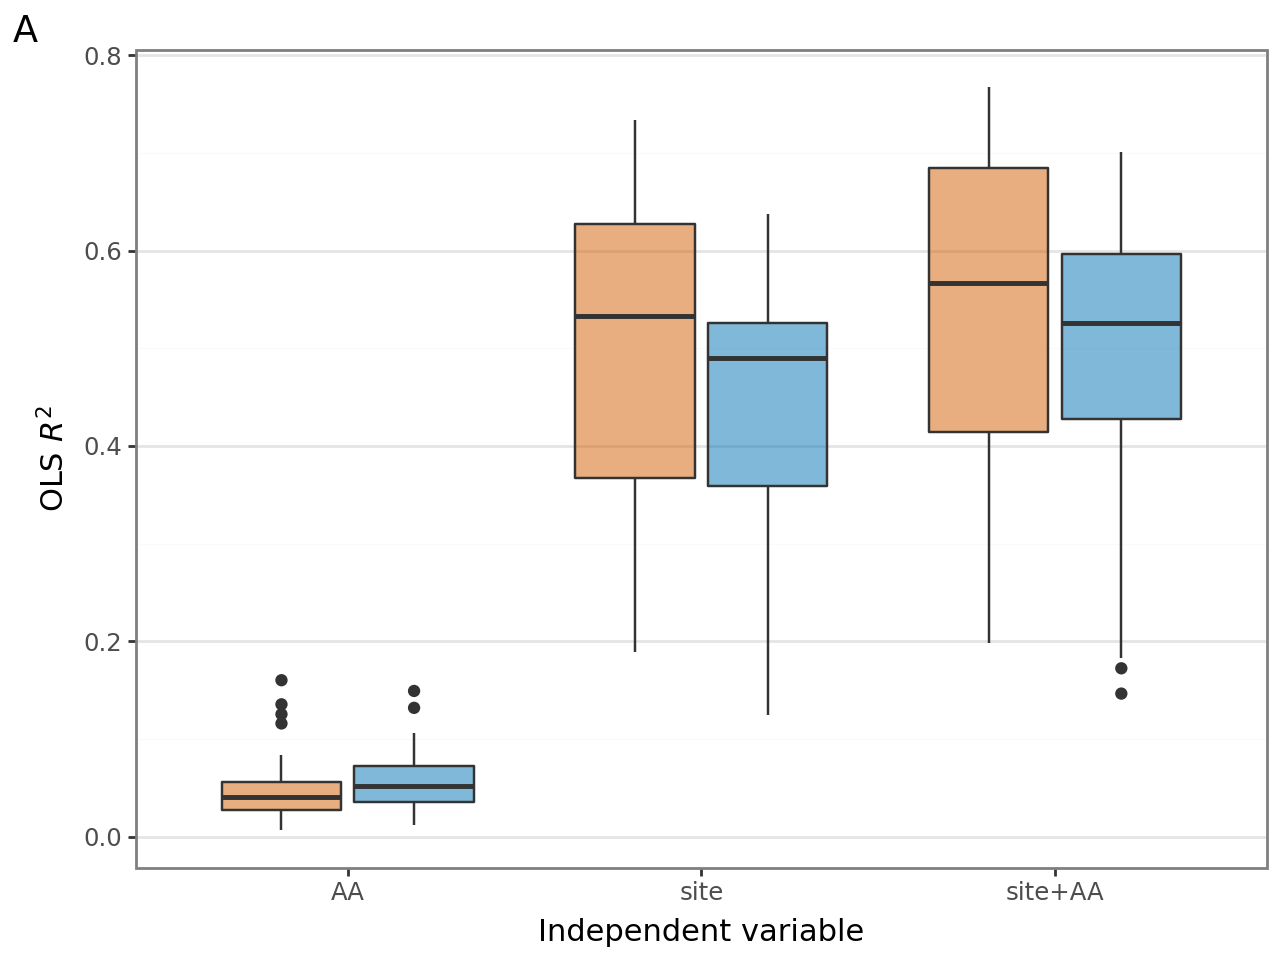

In [66]:
p1 = (
    #pln.ggplot(res_melt, pln.aes(y='R2', x='Source', color='Model'))
    pln.ggplot(res_melt, pln.aes(y='R2', x='Model', fill='Source'))
    + pln.scale_fill_manual(values={"Viral": "#D55E00", "Cellular": "#0072B2"})
    + pln.geom_boxplot(alpha=0.5)
    + pln.theme_bw()
    +pln.labs(
        y='OLS $R^2$',
        x='Independent variable',
        tag='A')
    + pln.theme(
        #figure_size=(5,4), 
        panel_grid_major_x=pln.element_blank(), 
        legend_position='none', 
        legend_title=pln.element_blank())
    )
    

p1#.save('../experiments/OLS/OLS_site_categorical_source.png', dpi=600)

# AVG vs AVG filtered

In [5]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [6]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

## AVG

In [7]:
AVG = pd.DataFrame()
for model in ['AVG']:
    for source in ['viral', 'cellular']:
        #for method in ['pool_split', 'site_split']:
        for method in ['pool_split']:
            res_dir_path = f'../experiments/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            AVG = pd.concat([AVG, res], ignore_index=True)

AVG

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,AVG,1,0.530925,0.511884,0.683361,0.424830,0.567484,0.765066,0.734405,0.669716,SARS2_PLPRO_abundance_Wu,viral,pool_split
1,AVG,2,0.521827,0.515027,0.691632,0.461210,0.551556,0.732446,0.731561,0.683581,SARS2_PLPRO_abundance_Wu,viral,pool_split
2,AVG,3,0.527835,0.510688,0.683042,0.433635,0.573968,0.768914,0.733999,0.671194,SARS2_PLPRO_abundance_Wu,viral,pool_split
3,AVG,1,0.632854,0.422123,0.603981,0.673508,0.412015,0.578420,0.761273,0.792606,LAMBDA_HCP_Tsuboyama,viral,pool_split
4,AVG,2,0.625207,0.427129,0.611822,0.692847,0.410369,0.553779,0.770798,0.752323,LAMBDA_HCP_Tsuboyama,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,AVG,2,0.263463,0.624286,0.853615,0.186157,0.681182,0.921145,0.471661,0.364794,B3VI55_LIPST_Whitehead2015,cellular,pool_split
218,AVG,3,0.275332,0.623867,0.845470,0.143653,0.690232,0.950018,0.473400,0.347827,B3VI55_LIPST_Whitehead2015,cellular,pool_split
219,AVG,1,0.549891,0.462756,0.676457,0.498551,0.507987,0.684111,0.740102,0.694642,RASH_HUMAN_Kuriyan,cellular,pool_split
220,AVG,2,0.554014,0.466393,0.670008,0.468630,0.499881,0.719181,0.740259,0.688316,RASH_HUMAN_Kuriyan,cellular,pool_split


In [8]:
AGV_grouped = AVG.groupby(['Dataset', 'Source', 'Model', 'Split',], as_index=False)['R2_score_test'].mean()
AGV_grouped

,Dataset,Source,Model,Split,R2_score_test
0,AMIE_PSEAE_Whitehead,cellular,AVG,pool_split,0.405258
1,B3VI55_LIPSTSTABLE,cellular,AVG,pool_split,0.254094
2,B3VI55_LIPST_Whitehead2015,cellular,AVG,pool_split,0.162333
3,BG_STRSQ_hmmerbit,cellular,AVG,pool_split,0.102000
4,BLAT_ECOLX_Ostermeier2014,cellular,AVG,pool_split,0.455095
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,AVG,pool_split,-0.028949
70,TPMT_HUMAN_Fowler2018,cellular,AVG,pool_split,0.229463
71,UBC9_HUMAN_Roth2017,cellular,AVG,pool_split,0.329162
72,UBE4B_MOUSE_Klevit2013_singles,cellular,AVG,pool_split,0.115625


## ESM2 

In [9]:
esm2_lasso = pd.DataFrame()
for model in ['esm2_650m']:
    for source in ['viral', 'cellular']:
        #for method in ['pool_split', 'site_split']:
        for method in ['pool_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
     
            res['Source'] = source
            res['Split'] = method
            esm2_lasso = pd.concat([esm2_lasso , res], ignore_index=True)

esm2_lasso

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Source,Split
0,esm2_650m,1,0.595066,0.465875,0.642610,0.499775,0.496724,0.678049,0.623398,0.544245,267,SARS2_PRD0038_RBD_Starr,viral,pool_split
1,esm2_650m,2,0.603862,0.452948,0.627526,0.520908,0.502435,0.700182,0.624444,0.596304,276,SARS2_PRD0038_RBD_Starr,viral,pool_split
2,esm2_650m,3,0.589508,0.472382,0.652183,0.407867,0.495722,0.709779,0.622881,0.528574,246,SARS2_PRD0038_RBD_Starr,viral,pool_split
3,esm2_650m,1,0.452034,0.520602,0.729537,0.231151,0.688557,0.925848,0.627984,0.397335,44,HIV1_HV1B9_ENV_DuenasDecamp,viral,pool_split
4,esm2_650m,2,0.503739,0.510456,0.698138,0.244454,0.645255,0.898591,0.658186,0.418242,53,HIV1_HV1B9_ENV_DuenasDecamp,viral,pool_split
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,esm2_650m,2,0.751425,0.367347,0.500301,0.495988,0.531824,0.698269,0.741263,0.503004,128,BRCA1_HUMAN_RING,cellular,pool_split
218,esm2_650m,3,0.785215,0.343243,0.468089,0.544591,0.483774,0.644829,0.747100,0.620093,155,BRCA1_HUMAN_RING,cellular,pool_split
219,esm2_650m,1,0.272134,0.630824,0.860391,0.167759,0.647026,0.879904,0.565655,0.469759,339,MK01_HUMAN_Johannessen,cellular,pool_split
220,esm2_650m,2,0.290257,0.619608,0.848874,0.142517,0.655648,0.896343,0.585867,0.439869,371,MK01_HUMAN_Johannessen,cellular,pool_split


In [10]:
esm2_lasscv_grouped = esm2_lasso.groupby(['Dataset', 'Source', 'Model', 'Split',], as_index=False)['R2_score_test'].mean()
esm2_lasscv_grouped

,Dataset,Source,Model,Split,R2_score_test
0,AMIE_PSEAE_Whitehead,cellular,esm2_650m,pool_split,0.477524
1,B3VI55_LIPSTSTABLE,cellular,esm2_650m,pool_split,0.451530
2,B3VI55_LIPST_Whitehead2015,cellular,esm2_650m,pool_split,0.245162
3,BG_STRSQ_hmmerbit,cellular,esm2_650m,pool_split,0.412022
4,BLAT_ECOLX_Ostermeier2014,cellular,esm2_650m,pool_split,0.653254
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,esm2_650m,pool_split,0.153564
70,TPMT_HUMAN_Fowler2018,cellular,esm2_650m,pool_split,0.434826
71,UBC9_HUMAN_Roth2017,cellular,esm2_650m,pool_split,0.422988
72,UBE4B_MOUSE_Klevit2013_singles,cellular,esm2_650m,pool_split,0.265605


## Merge

In [11]:
res = pd.concat([esm2_lasscv_grouped, AGV_grouped], axis=0)
res

,Dataset,Source,Model,Split,R2_score_test
0,AMIE_PSEAE_Whitehead,cellular,esm2_650m,pool_split,0.477524
1,B3VI55_LIPSTSTABLE,cellular,esm2_650m,pool_split,0.451530
2,B3VI55_LIPST_Whitehead2015,cellular,esm2_650m,pool_split,0.245162
3,BG_STRSQ_hmmerbit,cellular,esm2_650m,pool_split,0.412022
4,BLAT_ECOLX_Ostermeier2014,cellular,esm2_650m,pool_split,0.653254
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,AVG,pool_split,-0.028949
70,TPMT_HUMAN_Fowler2018,cellular,AVG,pool_split,0.229463
71,UBC9_HUMAN_Roth2017,cellular,AVG,pool_split,0.329162
72,UBE4B_MOUSE_Klevit2013_singles,cellular,AVG,pool_split,0.115625


In [12]:
res_pivot = pd.pivot_table(res, index=['Dataset','Source', 'Split'], columns= 'Model', values='R2_score_test').reset_index()
res_pivot

Model,Dataset,Source,Split,AVG,esm2_650m
0,AMIE_PSEAE_Whitehead,cellular,pool_split,0.405258,0.477524
1,B3VI55_LIPSTSTABLE,cellular,pool_split,0.254094,0.451530
2,B3VI55_LIPST_Whitehead2015,cellular,pool_split,0.162333,0.245162
3,BG_STRSQ_hmmerbit,cellular,pool_split,0.102000,0.412022
4,BLAT_ECOLX_Ostermeier2014,cellular,pool_split,0.455095,0.653254
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,pool_split,-0.028949,0.153564
70,TPMT_HUMAN_Fowler2018,cellular,pool_split,0.229463,0.434826
71,UBC9_HUMAN_Roth2017,cellular,pool_split,0.329162,0.422988
72,UBE4B_MOUSE_Klevit2013_singles,cellular,pool_split,0.115625,0.265605


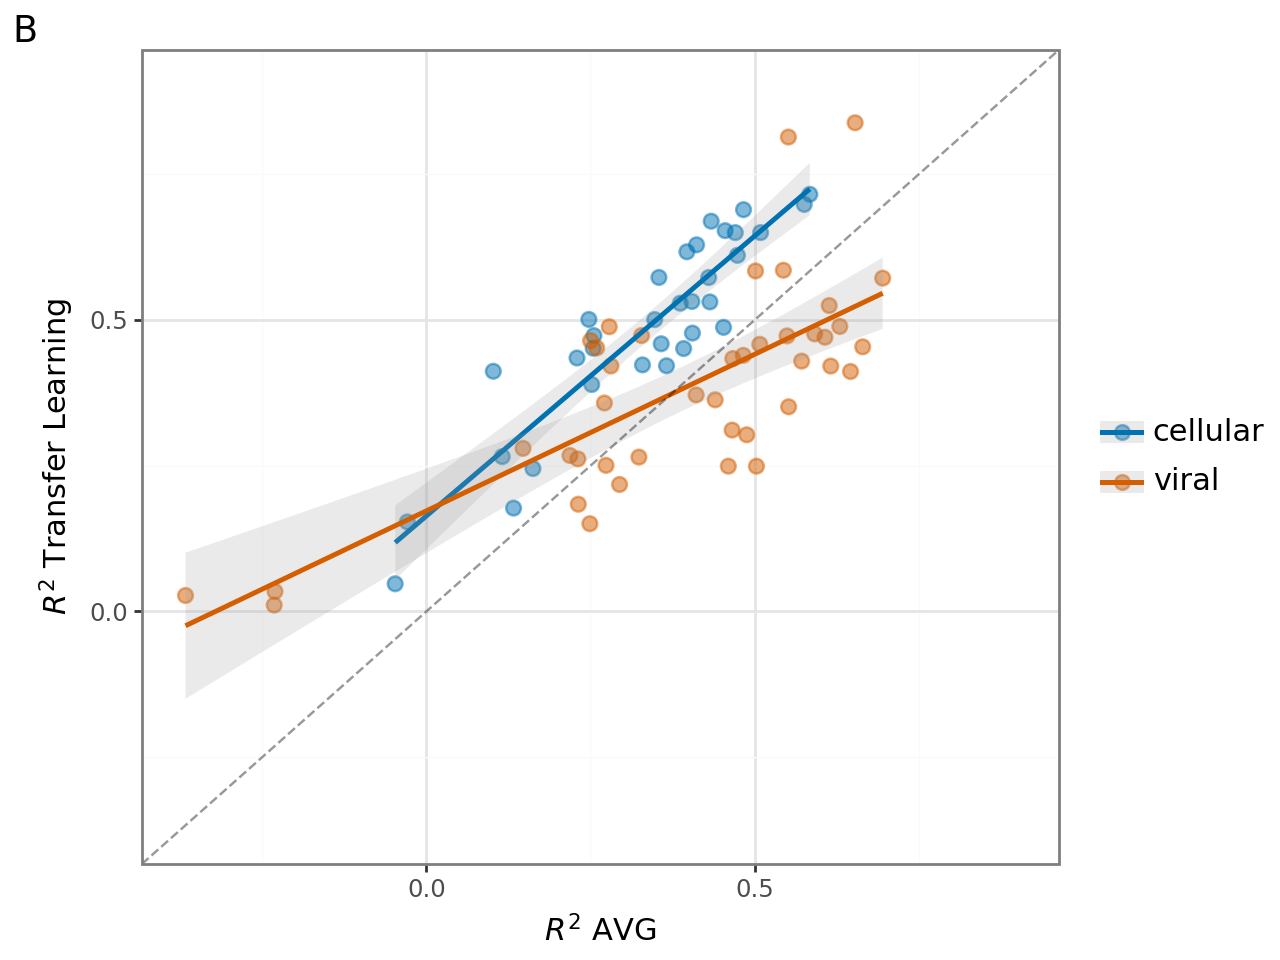

In [48]:
p2 = (
    pln.ggplot(res_pivot, pln.aes(x='AVG', y='esm2_650m', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=2.5, alpha=0.5)
    + pln.geom_smooth(method='lm', se=True, alpha=.2)
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.4, linetype='dashed')
    + pln.theme(
        #figure_size=(4.5,4),
        #legend_position=(-0.2,1.2),
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.xlim(-0.37, 0.9)
    + pln.ylim(-0.37, 0.9)
    + pln.labs(
        y="$R^2$ Transfer Learning",
        x="$R^2$ AVG",
        tag='B'
    )
    )

p2

## composition

In [67]:
comp = p1 | p2
plot = comp + pln.theme(figure_size=(8, 4), legend_position='top')
plot.save(filename='../experiments/comp2_lassoCV_x_AVG.png', dpi=600)

## AVG x All

In [38]:
avg = pd.read_csv('../experiments/AVG/results_AVG_3folds_all.csv', index_col=0)
avg = avg.query('Split == "pooled"')
avg

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,AVG,1,0.530925,0.511884,0.683361,0.424830,0.567484,0.765066,0.734405,0.669716,SARS2_PLPRO_abundance_Wu,viral,pooled
1,AVG,2,0.521827,0.515027,0.691632,0.461210,0.551556,0.732446,0.731561,0.683581,SARS2_PLPRO_abundance_Wu,viral,pooled
2,AVG,3,0.527835,0.510688,0.683042,0.433635,0.573968,0.768914,0.733999,0.671194,SARS2_PLPRO_abundance_Wu,viral,pooled
0,AVG,1,0.632854,0.422123,0.603981,0.673508,0.412015,0.578420,0.761273,0.792606,LAMBDA_HCP_Tsuboyama,viral,pooled
1,AVG,2,0.625207,0.427129,0.611822,0.692847,0.410369,0.553779,0.770798,0.752323,LAMBDA_HCP_Tsuboyama,viral,pooled
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,AVG,2,0.263463,0.624286,0.853615,0.186157,0.681182,0.921145,0.471661,0.364794,B3VI55_LIPST_Whitehead2015,cellular,pooled
2,AVG,3,0.275332,0.623867,0.845470,0.143653,0.690232,0.950018,0.473400,0.347827,B3VI55_LIPST_Whitehead2015,cellular,pooled
0,AVG,1,0.549891,0.462756,0.676457,0.498551,0.507987,0.684111,0.740102,0.694642,RASH_HUMAN_Kuriyan,cellular,pooled
1,AVG,2,0.554014,0.466393,0.670008,0.468630,0.499881,0.719181,0.740259,0.688316,RASH_HUMAN_Kuriyan,cellular,pooled


In [39]:
res_full = pd.DataFrame() 
for model in ['esm2_650m', 'esmc_600m', 'rsawhney_esm2_3B', 'esm2_viral_650m_MP15_partial_CRVDBv30', 'esm2_viral_650m_MP15_partial_URVDBv30']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            res_full = pd.concat([res_full, res], ignore_index=True)

rename_map = {
    'esm2_650m':'ESM-2 650M',
    'esmc_600m':'ESM C 600M',
    'esm2_viral_650m_MP15_partial_CRVDBv30':'ESM-2-CRVBD', 
    'esm2_viral_650m_MP15_partial_URVDBv30':'ESM-2-URVBD', 
    'rsawhney_esm2_3B':'ESM-2 3B Sawhney',
    'pool_split':'Random Split',
    'site_split':'Site Split',
    }

res_full.replace(rename_map, inplace=True)
res_full['prot_length'] = res_full['Dataset'].map(prot_lengths)
cols = avg.columns
res_full = res_full[cols].copy()
full_res = pd.concat([res_full, avg])
full_res

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,ESM-2 650M,1,0.595066,0.465875,0.642610,0.499775,0.496724,0.678049,0.623398,0.544245,SARS2_PRD0038_RBD_Starr,viral,Random Split
1,ESM-2 650M,2,0.603862,0.452948,0.627526,0.520908,0.502435,0.700182,0.624444,0.596304,SARS2_PRD0038_RBD_Starr,viral,Random Split
2,ESM-2 650M,3,0.589508,0.472382,0.652183,0.407867,0.495722,0.709779,0.622881,0.528574,SARS2_PRD0038_RBD_Starr,viral,Random Split
3,ESM-2 650M,1,0.452034,0.520602,0.729537,0.231151,0.688557,0.925848,0.627984,0.397335,HIV1_HV1B9_ENV_DuenasDecamp,viral,Random Split
4,ESM-2 650M,2,0.503739,0.510456,0.698138,0.244454,0.645255,0.898591,0.658186,0.418242,HIV1_HV1B9_ENV_DuenasDecamp,viral,Random Split
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,AVG,2,0.263463,0.624286,0.853615,0.186157,0.681182,0.921145,0.471661,0.364794,B3VI55_LIPST_Whitehead2015,cellular,pooled
2,AVG,3,0.275332,0.623867,0.845470,0.143653,0.690232,0.950018,0.473400,0.347827,B3VI55_LIPST_Whitehead2015,cellular,pooled
0,AVG,1,0.549891,0.462756,0.676457,0.498551,0.507987,0.684111,0.740102,0.694642,RASH_HUMAN_Kuriyan,cellular,pooled
1,AVG,2,0.554014,0.466393,0.670008,0.468630,0.499881,0.719181,0.740259,0.688316,RASH_HUMAN_Kuriyan,cellular,pooled


In [43]:
df_mean = full_res.groupby(['Source', 'Split', 'Model', 'Dataset', ], as_index=False)['R2_score_test'].mean()
df_mean['Model'] = pd.Categorical(df_mean['Model'], categories=['AVG', 'ESM-2 650M', 'ESM C 600M', 'ESM-2-CRVBD', 'ESM-2-URVBD', 'ESM-2 3B Sawhney'])
df_mean['Source'] = pd.Categorical(df_mean['Source'], categories=['viral', 'cellular'])
df_mean 

,Source,Split,Model,Dataset,R2_score_test
0,cellular,Random Split,ESM C 600M,AMIE_PSEAE_Whitehead,0.474063
1,cellular,Random Split,ESM C 600M,B3VI55_LIPSTSTABLE,0.409322
2,cellular,Random Split,ESM C 600M,B3VI55_LIPST_Whitehead2015,0.223819
3,cellular,Random Split,ESM C 600M,BG_STRSQ_hmmerbit,0.527707
4,cellular,Random Split,ESM C 600M,BLAT_ECOLX_Ostermeier2014,0.653661
...,...,...,...,...,...
438,viral,pooled,AVG,SARS2_PLPRO_activity_Wu,0.607093
439,viral,pooled,AVG,SARS2_PRD0038_RBD_Starr,0.591430
440,viral,pooled,AVG,SARS2_RBD_binding_Starr,0.613546
441,viral,pooled,AVG,SARS2_RBD_expression_Starr,0.695023


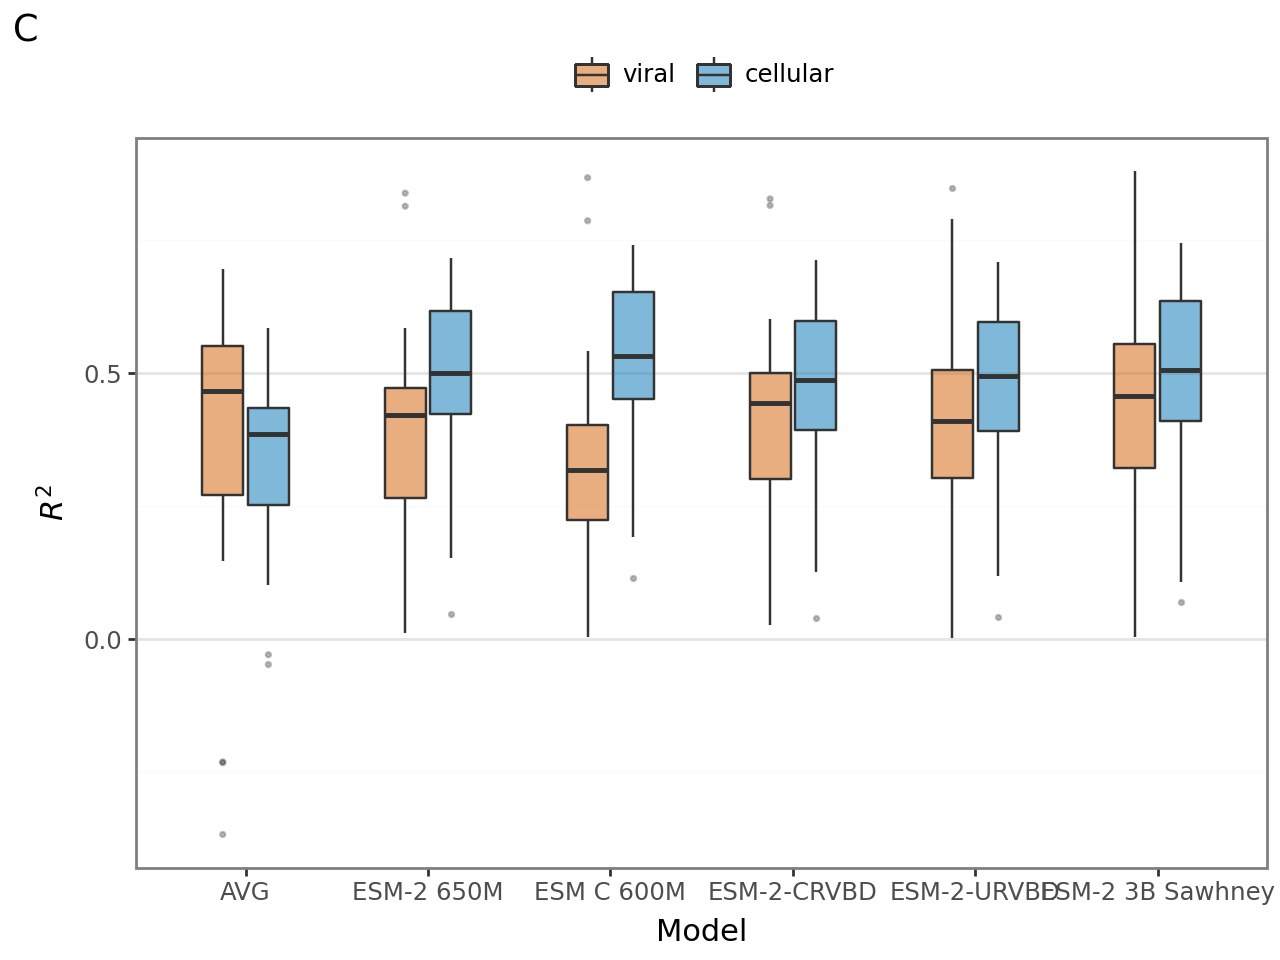

In [44]:
p3 = (
    pln.ggplot(df_mean , pln.aes(fill='Source', y='R2_score_test', x='Model'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5, alpha=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.labs(
        x='Model',
        y='$R^2$',
        tag='C'
    )
    + pln.theme_bw()
    + pln.theme(
        #figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank()
    )
)

p3#.save(filename='../experiments/lassoCV_x_AVG_all.png', dpi=600)

# Compose figure

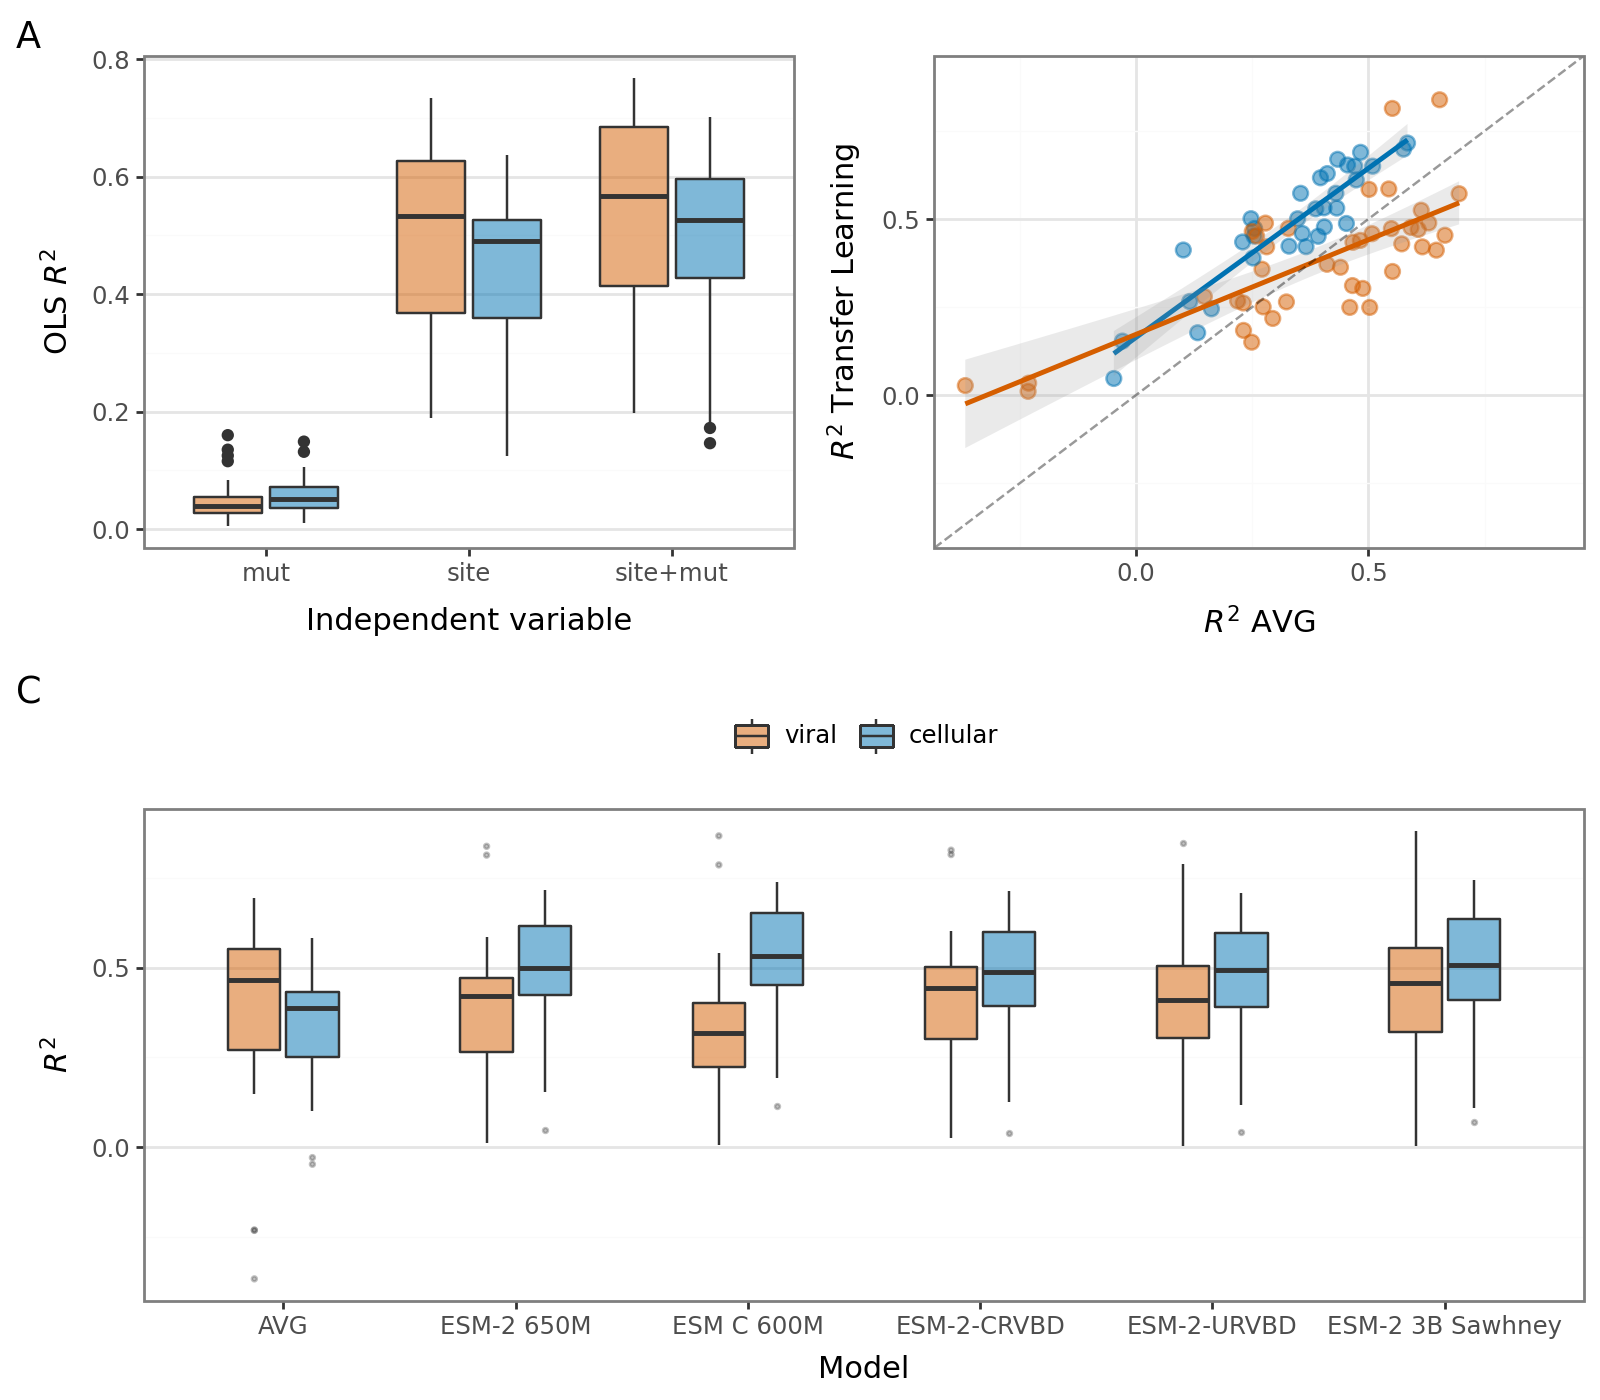

In [47]:
comp = (p1 | p2) / p3
plot = comp + pln.theme(figure_size=(8, 7.))
plot#.save(filename='../experiments/comp2_lassoCV_x_AVG.png', dpi=600)

In [ ]:
stop

NameError: name 'stop' is not defined

## AVG model vs finetuned model

In [ ]:
res_esm2 = pd.read_csv('../experiments_v01/fineTune/res_finetune_esm2_650m.csv', index_col=0)
res_esm2 = res_esm2[['Source', 'Dataset', 'split_strategy', 'val_r2']]
res_esm2 = res_esm2.rename(columns={'split_strategy':"Split", 'val_r2':'ESM-2_R2'})
replace_map = {'Pool Split':'pooled', 'Site Split':'site', 'Viral':'viral', 'Cellular':'cellular'}
res_esm2 = res_esm2.replace(replace_map)
res_esm2

,Source,Dataset,Split,ESM-2_R2
0,viral,BPP22_COAT_Tsuboyama,pooled,0.737966
1,viral,BPP22_COAT_Tsuboyama,site,0.615722
2,viral,CVB3_2A_Alvarez,pooled,0.463681
3,viral,CVB3_2A_Alvarez,site,0.106359
4,viral,CVB3_2B_Alvarez,pooled,0.393990
...,...,...,...,...
61,cellular,UBC9_HUMAN_Roth2017,site,0.144218
62,cellular,UBE4B_MOUSE_Klevit2013_singles,pooled,-0.010066
63,cellular,UBE4B_MOUSE_Klevit2013_singles,site,-0.000251
64,cellular,YAP1_HUMAN_Fields2012_singles,pooled,0.191104


In [ ]:
res = res_esm2.merge(res_avg, on=['Source', 'Dataset', 'Split'], how='inner')
res

,Source,Dataset,Split,ESM-2_R2,R2
0,viral,BPP22_COAT_Tsuboyama,pooled,0.737966,0.551416
1,viral,BPP22_COAT_Tsuboyama,site,0.615722,-0.047663
2,viral,CVB3_2A_Alvarez,pooled,0.463681,0.543750
3,viral,CVB3_2A_Alvarez,site,0.106359,-0.047608
4,viral,CVB3_2B_Alvarez,pooled,0.393990,0.259436
...,...,...,...,...,...
141,cellular,UBC9_HUMAN_Roth2017,site,0.144218,-0.017548
142,cellular,UBE4B_MOUSE_Klevit2013_singles,pooled,-0.010066,0.115625
143,cellular,UBE4B_MOUSE_Klevit2013_singles,site,-0.000251,-0.004356
144,cellular,YAP1_HUMAN_Fields2012_singles,pooled,0.191104,0.357715


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


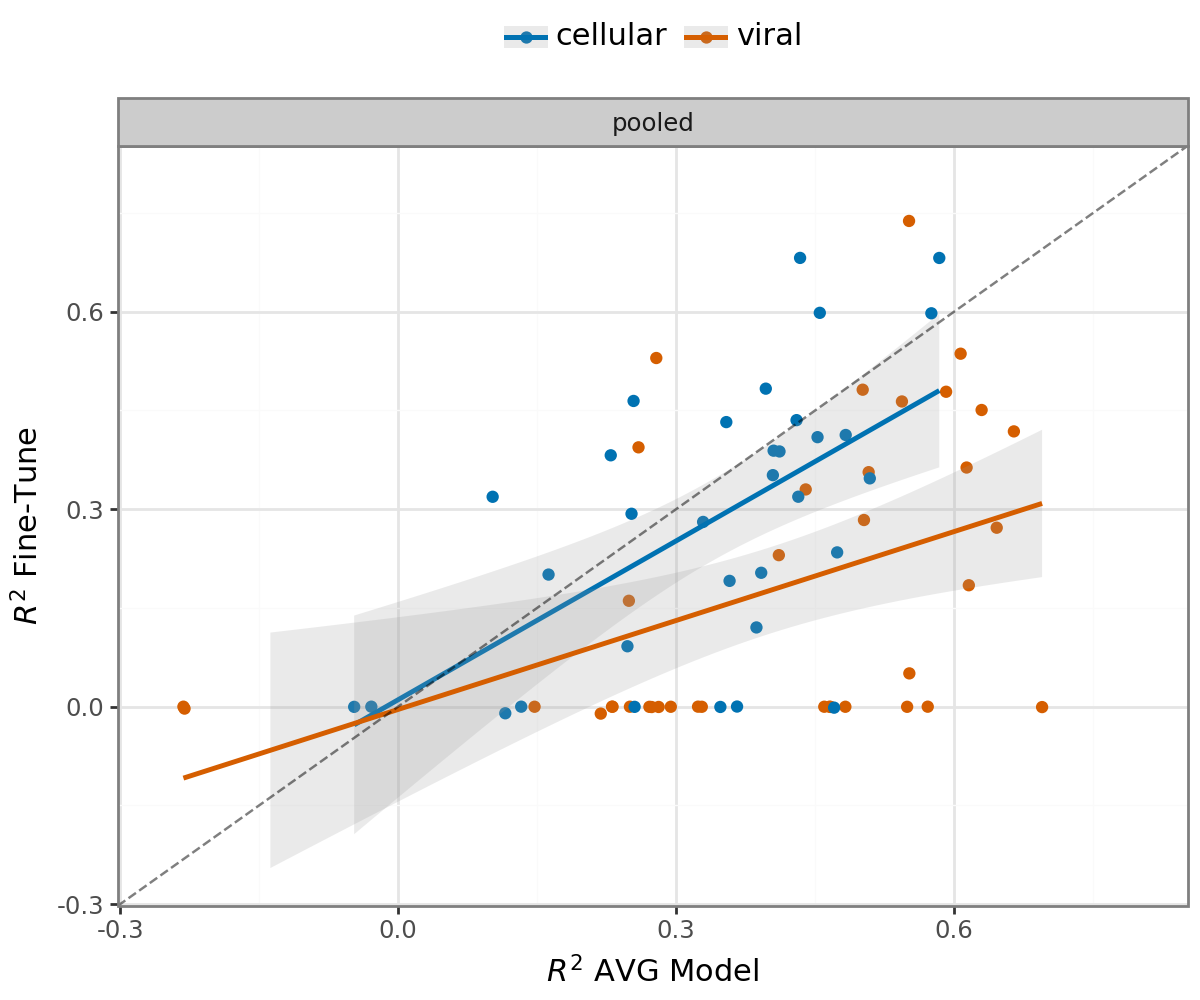

In [ ]:
plot = (
    pln.ggplot(res.query('Split == "pooled"'), pln.aes(y='ESM-2_R2', x='R2', color='Source', group='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme_bw(11)
    + pln.theme(
        figure_size=(6,5),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.facet_wrap('~Split', scales='fixed')
    + pln.xlim(-0.25, 0.8)
    + pln.ylim(-0.25, 0.8)
    + pln.labs(
        y="$R^2$ Fine-Tune",
        x="$R^2$ AVG Model"
    )
    )

plot#.save('../experiments/regression/diff_x_r2.png', dpi=600)

# Muation rates

In [ ]:
dfs = []

for source in ['viral', 'cellular']:
    res = {}
    base_dir = f'../data/{source}/metadata/'
    for file in os.listdir(base_dir):
        file_path = os.path.join(base_dir, file)
        dts = file.split('.csv')[0]
        data = pd.read_csv(file_path)
        
        data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
        data['site'] = data['site'].astype(str)
        
        num_mut = len(data['site'].unique())
        protein_length = len(data['sequence'].iloc[0])
        ratio = num_mut / protein_length
    
        res[dts] = [num_mut, protein_length, round(ratio, 3)]
    
    # Create dataframe for this source after processing all files
    df = pd.DataFrame.from_dict(res, orient='index').reset_index()
    df.rename(columns={'index': 'Dataset', 0: '#mutations', 1: 'prot_len', 2: 'ratio'}, inplace=True)
    df['Source'] = source
    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)
final_df

,Dataset,#mutations,prot_len,ratio,Source
0,HIV1_HV1B9_ENV_DuenasDecamp,20,853,0.023,viral
1,BPP22_COAT_Tsuboyama,40,40,1.000,viral
2,AAV2_CAPSD_Sinai,28,735,0.038,viral
3,IAV_RDRP_Li,754,757,0.996,viral
4,EV_CAPSD_Bakhache,862,862,1.000,viral
...,...,...,...,...,...
74,B3VI55_LIPST_Whitehead2015,439,439,1.000,cellular
75,B3VI55_LIPSTSTABLE,439,439,1.000,cellular
76,RL401_YEAST_Bolon2013,75,128,0.586,cellular
77,RL401_YEAST_Bolon2014,75,128,0.586,cellular


In [ ]:
final_df.to_csv('../experiments/mutation_rations.csv')

In [ ]:
final_df.groupby(['Source'])['ratio'].mean()

Source
cellular    0.638543
viral       0.840091
Name: ratio, dtype: float64

In [ ]:
final_df.groupby(['Source'])['prot_len'].mean()

Source
cellular    442.485714
viral       569.750000
Name: prot_len, dtype: float64

In [ ]:
final_df.groupby(['Source'])['#mutations'].mean()

Source
cellular    191.171429
viral       420.568182
Name: #mutations, dtype: float64

In [ ]:
plot = (
    pln.ggplot(final_df, pln.aes(x='ratio', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    +pln.geom_density(alpha=0.6)
    +pln.theme_bw()

)

plot#.save('../experiments/mutation_rations.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../experiments/mutation_rations.png
